# Seq2Seq (Sequence-to-Sequence)

### Embedding Vector 준비

1. 영어 glove 임베딩 (사전학습) 사용
2. 한국어 임베딩(초기훈련)

### 학습 데이터 준비

http://www.manythings.org/anki/

1. Encoder 입력 데이터 eng
    - encoder_input_eng 준비 `I love you`
2. Decoder 출력 데이터 kor
    - 학습용 teacher-forcing 모델
        - decoder_input_kor `<sos> 난 널 사랑해`
        - docoder_output_kor `난 널 사랑해 <eos>`
    - 추론용 모델

In [64]:
# 데이터 정재
eng_inputs = []     # 영어 원문 리스트
kor_inputs = []     # 한국어 입력 데이터 (디코더 입력 : <sos> 시작토큰 포함)
kor_targets = []    # 한국어 타겟 (디코더 정답 : <eos> 종료토큰 포함)

with open('eng_kor.txt', 'r', encoding='utf-8') as f:
    for line in f:
        eng, kor, _ = line.split('\t')  # line 형태 : 영어 \t 한국어 \t (기타)
        
        kor_input = '<sos> ' + kor   # 디코더 입력 시작토큰 추가
        kor_target = kor + ' <eos>'  # 디코더 정답 종료토큰 추가
        
        eng_inputs.append(eng)
        kor_inputs.append(kor_input)
        kor_targets.append(kor_target)
        
len(eng_inputs), len(kor_inputs), len(kor_targets)

(5890, 5890, 5890)

In [65]:
# 전처리 확인
print(eng_inputs[2500:2505])
print(kor_inputs[2500:2505])
print('---')
print(kor_targets[2500:2505])

['I speak French a little.', 'I take back what I said.', 'I tried to make friends.', 'I use this all the time.', 'I use this all the time.']
['<sos> 저는 프랑스어를 조금 합니다.', '<sos> 아까 한 말 취소야.', '<sos> 난 친구를 만드려고 했어.', '<sos> 나는 항상 이걸 쓴다.', '<sos> 매번 이걸 쓴다.']
---
['저는 프랑스어를 조금 합니다. <eos>', '아까 한 말 취소야. <eos>', '난 친구를 만드려고 했어. <eos>', '나는 항상 이걸 쓴다. <eos>', '매번 이걸 쓴다. <eos>']


# 토큰화



In [66]:
VOCAB_SIZE = 10000

# 영문 토큰화   
from tensorflow.keras.preprocessing.text import Tokenizer 

eng_tokenizer = Tokenizer(num_words = VOCAB_SIZE, oov_token= '<unk>')
eng_tokenizer.fit_on_texts(eng_inputs)      
eng_inputs_seq = eng_tokenizer.texts_to_sequences(eng_inputs)

eng_inputs_seq[2500:2505]

[[2, 130, 38, 8, 268],
 [2, 111, 150, 27, 2, 82],
 [2, 300, 4, 213, 202],
 [2, 206, 12, 54, 6, 60],
 [2, 206, 12, 54, 6, 60]]

In [67]:
for seq in eng_inputs_seq[2500:2505]:
    print([eng_tokenizer.index_word[idx] for idx in seq])   # 각 ID를 단어로 역변환 해서 확인

['i', 'speak', 'french', 'a', 'little']
['i', 'take', 'back', 'what', 'i', 'said']
['i', 'tried', 'to', 'make', 'friends']
['i', 'use', 'this', 'all', 'the', 'time']
['i', 'use', 'this', 'all', 'the', 'time']


In [68]:
eng_num_words = min(VOCAB_SIZE, len(eng_tokenizer.word_index))  # 실제 사용어휘 수 (VOCAB_SIZE와 사전 크기중 작은값)
eng_max_len = max([len(seq) for seq in eng_inputs_seq])     # 영어 시퀀스 중 가장 긴 문장 토큰 길이 (패딩용 체크)

eng_num_words, eng_max_len

(3200, 101)

# 국문 토큰화   

In [69]:
# 필터 기본값 : '!"#$%&()*+,-./:;<=>?@[\]^_`{|}~\t\n'
kor_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token= '<OOV>', filters='')     # 필터 제거
# 입력 + 타겟 전체로 단어사전 학습(생성) : <sos>, <eos> 토큰 포함
kor_tokenizer.fit_on_texts(kor_inputs + kor_targets)   

kor_inputs_seq = kor_tokenizer.texts_to_sequences(kor_inputs)   # 한국어 입력 -> ID 시퀀스
kor_targets_seq = kor_tokenizer.texts_to_sequences(kor_targets) # 한국어 타겟 -> ID 시퀀스

In [70]:
kor_inputs_seq[2500:2505]

[[2, 196, 40, 295, 704],
 [2, 4264, 33, 223, 4265],
 [2, 7, 564, 4266, 69],
 [2, 5, 156, 137, 396],
 [2, 1974, 137, 396]]

In [71]:
kor_num_words = min(VOCAB_SIZE, len(kor_tokenizer.index_word))  # 실제 사용하는 어휘 수 
# 한국어 입력 시퀀스 중 가장 긴 길이(<sos> 시작토큰 포함)
kor_max_len = max([len(seq) for seq in kor_inputs_seq])
    
kor_num_words, kor_max_len

(8288, 90)

# 패딩처리 
- 인코더 padding = 'pre'
- 디코더 padding = 'post

In [72]:
from tensorflow.keras.preprocessing.sequence import pad_sequences   # 패딩 / 트런케이팅 함수

# 영어 입력은 최대토큰 길이
eng_inputs_padded = pad_sequences(eng_inputs_seq, maxlen=eng_max_len, padding= 'pre')
kor_inputs_padded = pad_sequences(kor_inputs_seq, maxlen=kor_max_len, padding= 'post')
kor_targets_padded = pad_sequences(kor_targets_seq, maxlen=kor_max_len, padding= 'post')

영어 (Encoder 입력) pre 패딩 : 마지막 hidden state 사용. 끝부분이 0으로 끝나지 않고 실제 단어가 오게 함.  
한국어 (Decoder 입력/ 타겟) post 패딩 : 기본적으로 생성시 왼쪽 -> 오른쪽 생성(teacher forcing)이  
앞에서부터의 시점 정렬이 자연스럽게 되고, 뒤에만 0을 붙여 차후 loss 마스킹/처리에 쉬워짐.

# 모델 생성
encoder + decoder (teacher_forcing) 구조의 모델 생성 및 학습

In [73]:
with open('glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for i, vects in enumerate(f):   # 한 줄씩 읽음
        print(vects)
        if i == 3:
            break

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062

, -0.10767 0.11053 0.59812 -0.54361 0.67396 0.10663 0.038867 0.35481 0.06351 -0.094189 0.15786 -0.81665 0.14172 0.21939 0.58505 -0.52158

In [74]:
import numpy as np

# 토크나이저의 단어 인덱스에 맞춰 사전학습 임베딩으로 embedding_matrix 를 만드는 함수
def make_embedding_matrix(num_words, embedding_dim, tokenizer, file_path):
    embedding_matrix = np.zeros((num_words+1, embedding_dim))
    
    pretrained_embedding = {}   # 사전학습 임베딩 저장 {word : vectors}
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            word, *vects = line.split()        # 첫번째 토큰은 word, 나머지는 vector 값들
            vects = np.array(vects, dtype=np.float32)   # 문자열 벡터값 -> float32 ndarray 변환
            pretrained_embedding[word] = vects
            
    for word, index in tokenizer.word_index.items():
        vects_ = pretrained_embedding.get(word)     # 해당 단어의 사전학습 벡터 조회(없으면 None)
        if vects_ is not None:      # 임베딩 존재시 
            embedding_matrix[index] = vects_    # 해당 인덱스 위치에 벡토로 수정
                
    return embedding_matrix     # 만약 사전학습 임베딩에 없는 단어는 0 벡터

In [75]:
EMBEDDING_DIM = 100     # 사용할 임베딩 차원(사전학습된 임베딩 차원 100차원)

en_embedding_matrix = make_embedding_matrix(
    eng_num_words,      # 사용할 어휘 수
    EMBEDDING_DIM,      # 임베딩 차원
    eng_tokenizer,      # 영어 토크나이저(단어 -> 인덱스 사전 보유)
    'glove.6B.100d.txt')    # 임베딩 사전학습 파일 경로

en_embedding_matrix.shape   # (eng_num_words +1 (패딩), embedding_dim)

(3201, 100)

In [76]:
# 영어 인덱스 -> 단어 리스트 생성(패딩 토큰 추가)
eng_word_index = ['<PAD>'] + list(eng_tokenizer.index_word.values())
eng_word_index

['<PAD>',
 '<unk>',
 'i',
 'tom',
 'to',
 'you',
 'the',
 'is',
 'a',
 'that',
 'do',
 'in',
 'this',
 'was',
 'have',
 'he',
 "i'm",
 'my',
 'are',
 'of',
 "don't",
 'it',
 'me',
 'be',
 'your',
 'like',
 'for',
 'what',
 'want',
 'think',
 'we',
 'know',
 'not',
 'mary',
 'his',
 'there',
 'how',
 'can',
 'french',
 'and',
 'very',
 'has',
 "it's",
 'at',
 'go',
 'with',
 'she',
 'did',
 "didn't",
 'on',
 'here',
 'why',
 'going',
 'been',
 'all',
 'no',
 'as',
 'really',
 'help',
 'please',
 'time',
 "can't",
 'they',
 'will',
 'him',
 "isn't",
 'one',
 "you're",
 'if',
 'about',
 'good',
 "that's",
 'who',
 'too',
 "doesn't",
 'up',
 'had',
 'were',
 'where',
 'would',
 'from',
 "tom's",
 'said',
 'need',
 'something',
 'when',
 'us',
 'tell',
 'never',
 'home',
 'now',
 'still',
 'more',
 'school',
 'so',
 'an',
 'should',
 'come',
 'than',
 'some',
 'sorry',
 'but',
 'ever',
 'get',
 'work',
 'out',
 "i'll",
 "i've",
 'three',
 'by',
 'boston',
 'take',
 'keep',
 'stop',
 'just',

In [77]:
import pandas as pd

pd.DataFrame(en_embedding_matrix, index= eng_word_index)    # 행= index(단어), 열 = 임베딩 차원값

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
<PAD>,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
<unk>,0.283650,-0.626300,-0.44351,0.217700,-0.087421,-0.170620,0.292660,-0.024899,0.264140,-0.17023,...,0.138850,-0.228620,0.071792,-0.432080,0.539800,-0.085806,0.032651,0.436780,-0.826070,-0.157010
i,-0.046539,0.619660,0.56647,-0.465840,-1.189000,0.445990,0.066035,0.319100,0.146790,-0.22119,...,-0.323430,-0.431210,0.413920,0.283740,-0.709310,0.150030,-0.215400,-0.376160,-0.032502,0.806200
tom,-0.583880,-0.469400,0.16855,-1.670300,-0.116010,0.048738,-0.342010,-0.376910,-0.953080,-0.88260,...,0.264290,0.337860,0.357910,0.549010,0.006725,0.281580,0.343730,0.137040,0.089572,-0.542770
to,-0.189700,0.050024,0.19084,-0.049184,-0.089737,0.210060,-0.549520,0.098377,-0.201350,0.34241,...,-0.131340,0.058617,-0.318690,-0.614190,-0.623930,-0.415480,-0.038175,-0.398040,0.476470,-0.159830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
whom,0.341680,0.545720,-0.15683,-0.205450,-0.199470,0.389270,-0.017266,-0.244750,0.124760,-0.34392,...,0.142210,-0.556420,0.457640,-0.243960,-1.146800,0.330140,-0.900430,-0.014213,0.161420,-0.444830
intimately,-0.416930,0.131300,0.50615,0.034870,0.255630,0.409070,0.234080,-0.574340,0.293270,0.14061,...,-0.636420,0.066336,-0.449260,-1.350100,0.381640,-0.051961,-0.425590,-0.667450,0.009747,0.061855
millions,0.622040,1.063600,0.13146,-0.203880,0.555570,0.443570,-0.524210,0.040587,0.470640,-0.53788,...,-0.063191,-0.111260,0.666090,-0.972050,-0.558910,-0.837910,-0.147160,0.862920,0.302910,-0.225640
inhabit,-0.927750,0.738860,0.69884,0.138580,0.020592,0.521490,-0.541050,0.501790,0.206630,-0.51982,...,0.491800,-0.235440,0.482430,-0.714400,-0.378190,0.271660,-1.243600,-0.288030,0.065840,0.053163


### 인코더 모델

In [ ]:
# Seq2Seq Encoder 모델 구성 (사전학습 임베딩 + LSTM)
from tensorflow.keras import layers, models     # keras 레이어/ 모델 구성 모듈

LATENT_DIM = 512    # LSTM 은닉 상태 차원

encoder_inputs = layers.Input(shape= (eng_max_len,))    # (B, eng_max_len) 형태의 단어 ID
# 사전학습된 임베딩 가중치로 Embedding 레이어 구성
en_embedding_layer = layers.Embedding(eng_num_words+1, EMBEDDING_DIM, weights=[en_embedding_matrix])
x= en_embedding_layer(encoder_inputs)   # (B, eng_max_len) -> (B, eng_max_len, EMBEDDING_DIM) 임베딩 차원 추가
# 마지막 출력, 최종 H(hidden), C(cell state) 반환
encoder_outputs, h, c = layers.LSTM(LATENT_DIM, return_state= True)(x)  
encoder_states =[h, c]  # 디코더로 전달할 encoder state 묶어 전달

# 모델 객체 생성 : Encoder 입력 -> (h, c) 출력
encoder_model = models.Model(inputs = encoder_inputs, outputs = encoder_states)

In [79]:
encoder_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 101)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 101, 100)       │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ [(None, 512), (None,   │     1,255,424 │
│                                 │ 512), (None, 512)]     │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,575,524 (6.01 MB)

 Trainable params: 1,575,524 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

##### 디코더 모델(Teacher-Forcing)

In [ ]:
# Seq2Seq Decoder 모델 (Teacher Forcing 학습용)
decoder_inputs = layers.Input(shape=(kor_max_len,))     # (B, kor_max_len) 형태 디코더
ko_embedding_layer = layers.Embedding(kor_num_words+1, EMBEDDING_DIM)   # 한국어 단어 ID -> 임베딩 레이어
x = ko_embedding_layer(decoder_inputs)  # (B, kor_max_len) -> (B, kor_max_len, EMBEDDING_DIM)

# 디코더 LSTM 모델 : 시퀀스 전체 출력 + state(h, c) 모두 반환
decoder_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True)    
# 인코더 출력 state(h, c)를 초기상태로 넣어 디코더 수행
x, h, c = decoder_lstm(x, initial_state= encoder_states)   

# 각 시점별 다음 단어 확률 분포(어휘 크기)
decoder_dense = layers.Dense(kor_num_words+1, activation= 'softmax')    
decoder_outputs = decoder_dense(x)  # 소프트맥스 확률(B, kor_max_len, kor_num_words+1)

decoder_teacher_forcing_model = models.Model(
    inputs = [encoder_inputs, decoder_inputs],  # 입력 : 영어 인코더 입력 + 한국어 디코더 입력
    outputs = decoder_outputs                   # 출력 : 한국어 다음 단어 분포(시점별)
)

decoder_teacher_forcing_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 101)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 90)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 101, 100)  │    320,100 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 90, 100)   │    828,900 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 512),     │  1,255,424 │ embedding[0][0]   │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 90, 512), │  1,255,424 │ embedding_1[0][0… │
│                     │ (None, 512),      │            │ lstm[0][1],       │
│                     │ (None, 512)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 90, 8289)  │  4,252,257 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,912,105 (30.18 MB)

 Trainable params: 7,912,105 (30.18 MB)

 Non-trainable params: 0 (0.00 B)

In [93]:
# Seq2Seq 모델 컴파일 및 학습
from tensorflow.keras.callbacks import CSVLogger    # 학습로그 csv로 저장하는 콜백

csv_logger = CSVLogger('trian_log.csv', append= True)   # 기존 파일에 기록이 있으면 추가

# 학습설정(손실함수/ 최적화함수/ 평가지표)
decoder_teacher_forcing_model.compile(
    loss = 'sparse_categorical_crossentropy',   # 정답이 정수 ID일 경우 사용하는 다중분류 손실함수
    optimizer= 'adam',
    metrics=['accuracy']
)

history = decoder_teacher_forcing_model.fit(
    [eng_inputs_padded, kor_inputs_padded],     # 입력 : 영어(인코더) + 한국어(디코더 입력, <sos> 시작토큰 포함)
    kor_targets_padded,     # 정답 : 한국어 타겟 시퀀스(<eos> 종료토큰 포함)
    batch_size= 64,         # 배치크기
    epochs= 70,             # 학습 반복횟수
    validation_split= 0.2,  # 검증데이터 20 %
    callbacks= [csv_logger] # epoch 마다 csv 로그 저장
)

Epoch 1/70
74/74 ━━━━━━━━━━━━━━━━━━━━ 483s 6s/step - accuracy: 0.9395 - loss: 1.0454 - val_accuracy: 0.9243 - val_loss: 0.6701
Epoch 2/70
30/74 ━━━━━━━━━━━━━━━━━━━━ 3:48 5s/step - accuracy: 0.9610 - loss: 0.3280

KeyboardInterrupt: 

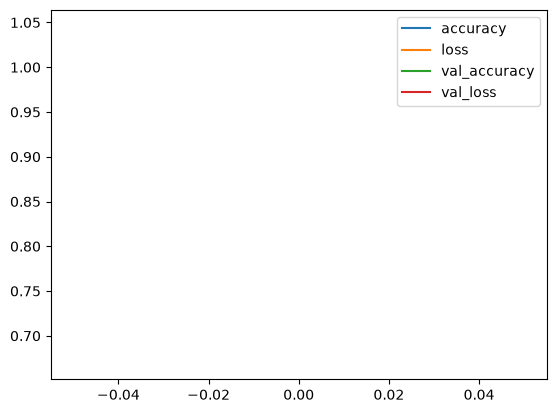

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('trian_log.csv')
df = df.drop(columns=['epoch']).plot()
plt.show()

In [104]:
# 모델 저장
decoder_teacher_forcing_model.save('decoder_teacher_forcing_model.keras')
decoder_teacher_forcing_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 101)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 90)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 101, 100)  │    320,100 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 90, 100)   │    828,900 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 512),     │  1,255,424 │ embedding[0][0]   │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 90, 512), │  1,255,424 │ embedding_1[0][0… │
│                     │ (None, 512),      │            │ lstm[0][1],       │
│                     │ (None, 512)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 90, 8289)  │  4,252,257 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,736,317 (90.55 MB)

 Trainable params: 7,912,105 (30.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,824,212 (60.36 MB)

In [ ]:
# 추론 모델
decoder_hidden_state = layers.Input(shape=(LATENT_DIM,))    # 이전 시점 H(hidden_dim)
decoder_cell_state = layers.Input(shape=(LATENT_DIM,))      # 이전 시점 C(Cell State)
decoder_states_inputs = [decoder_hidden_state, decoder_cell_state]  # (h, c) 상태 묶어 디코더 입력

decoder_single_input = layers.Input(shape=(1, ))    # 추론시 1개 토큰 (ID ) 만 입력(B. 1)
x= ko_embedding_layer(decoder_single_input)         # (B, 1) -> (B, 1, EMBEDDING_DIM)

x, h, c = decoder_lstm(x, initial_state = decoder_states_inputs)    # 입력토큰 + 이전상태 (H,C) 로 다음상태 기억
decoder_states = [h, c]     # 다음 스텝에 넘길 상태 (H.C) 저장

decoder_outputs_ = decoder_dense(x) # (B, 1, kor_num_word+ 1) 다음단어 확률 분포 출력

decoder_inference_model = models.Model(
    inputs = [decoder_single_input] + decoder_states_inputs,    # 입력 : 현재 토큰 + 이전 상태(h,c)
    outputs = [decoder_outputs_] + decoder_states
)



In [106]:
decoder_inference_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 100)    │    828,900 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 1, 512),  │  1,255,424 │ embedding_1[1][0… │
│                     │ (None, 512),      │            │ input_layer_2[0]… │
│                     │ (None, 512)]      │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 8289)   │  4,252,257 │ lstm_1[1][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,336,581 (24.17 MB)

 Trainable params: 6,336,581 (24.17 MB)

 Non-trainable params: 0 (0.00 B)

In [109]:

# 번역 함수 : 입력 영어 시퀀스를 인코더로 state 변환 후, <sos> 부터 시작해서 한 단어씩 생성하는 번역함수
def translate(input_seq):
    encoder_states_value = encoder_model.predict(input_seq) # 인코더에서 초기 상태 (h,c ) 추출
    decoder_states_value = encoder_states_value     # 디코더 초기 상태로 설정
    
    sos_index = kor_tokenizer.word_index['<sos>']   # 시작토큰 ID
    eos_index = kor_tokenizer.word_index['<eos>']   # 종료토큰 ID
    
    target_seq = np.zeros((1,1))    # 디코더 입력(현재 토큰) 자리 (B=1, 길이 = 1)
    target_seq[0,0] = sos_index     # 첫 입력 토큰은 <sos> 토큰으로 세팅
    
    
    output_sentences = []       # 생성된 단어(토큰) 들을 담을 리스트
    
    for _ in range(kor_max_len):    # 최대 길이는 한글 토큰 길이로 설정
        # (현재 토큰 + 이전 state)로 다음 토큰 분포와 state 예측
        output_tokens, h, c = decoder_inference_model.predict(
            [target_seq] + decoder_states_value
        )
        
        pred_proba = output_tokens[0,0, :]
        pred_index = np.argmax(pred_proba)
        
        # 종료 토큰 나오면 문장생성 종료
        if pred_index == eos_index:
            break
        
        # 패딩 토큰이 아닐 경우에만
        if pred_index > 0:
            word = kor_tokenizer.index_word[pred_index] # 실제 단어로 역변환
            output_sentences.append(word)               # 문장 토큰 하나씩 리스트에 추가
            
        target_seq[0, 0] = pred_index       # 이번 예측 토큰은 다음 스탭 입력으로 갱신
        decoder_states_value = [h, c]       # 현재 state도 다음 스텝 입력으로 갱신
    
    return ' '.join(output_sentences)

In [110]:
def translate_eng2kor(eng_text):
    input_seq = eng_tokenizer.texts_to_sequences(eng_text)
    input_seq = pad_sequences(input_seq, maxlen= eng_max_len)
    return translate(input_seq)


eng_texts = [
    'My hair is black', 'French is interesting.', 'I like bus.', "Let\'s study", 'I ate sandwich'
]

for eng_text in eng_texts:
    kor_text = translate_eng2kor([eng_text])
    display(eng_text, kor_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step


'My hair is black'

'톰은'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


...

"Let's study"

'톰은'

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step


'I ate sandwich'

'톰은'